In [5]:
pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.0 MB 171.1 kB/s eta 0:04:15
   ---------------------------------------- 0.5/44.0 MB 171.1 kB/s eta 0:04:15
   ---------------------------------------- 0.5/44.0 MB 171.1 kB/s eta 0


[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


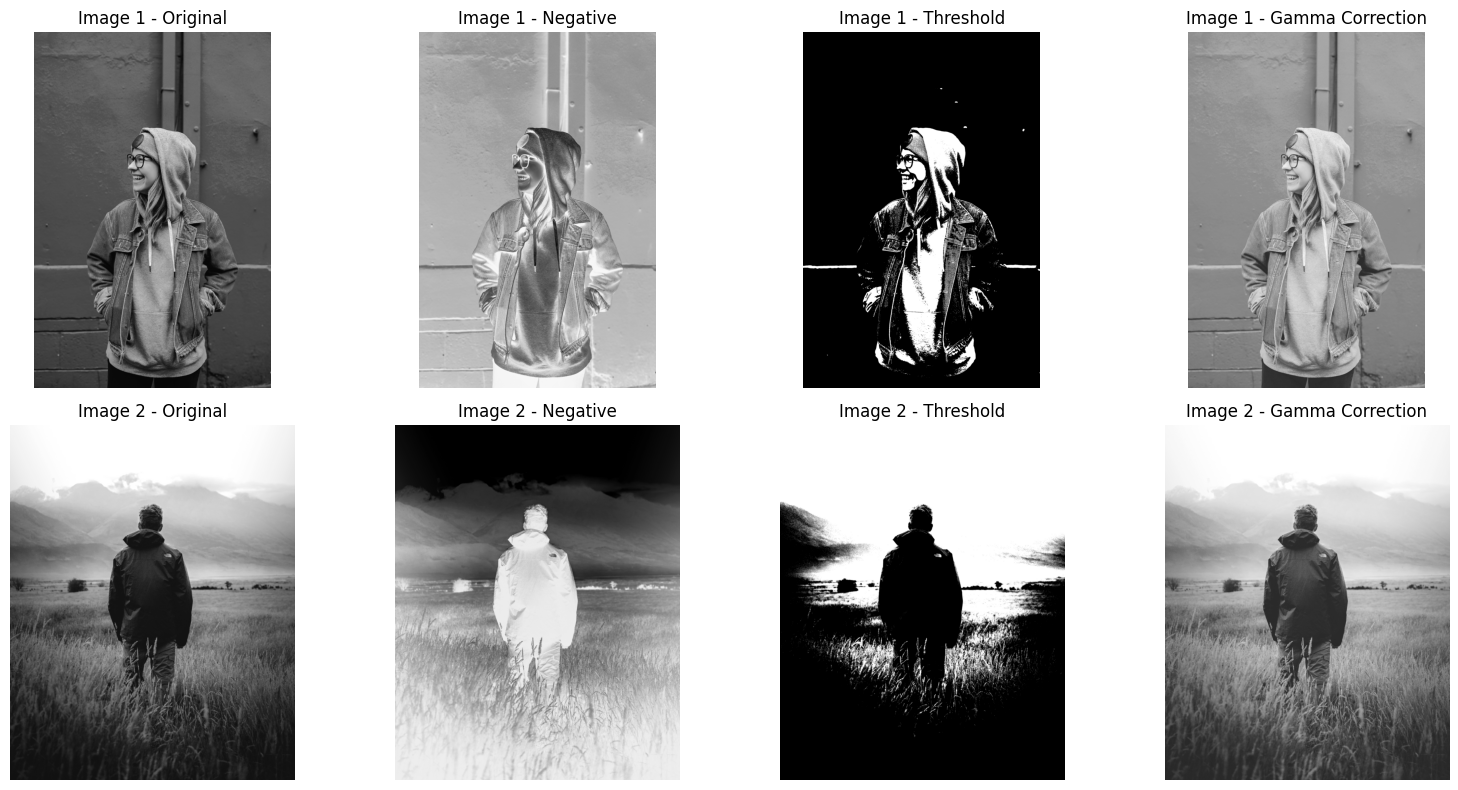

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------
# Online Image URLs
# --------------------------------------------

url1 = "https://images.unsplash.com/photo-1517841905240-472988babdf9"
url2 = "https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d"

# --------------------------------------------
# Read images from URLs
# --------------------------------------------

image1 = cv2.imdecode(
    np.frombuffer(
        __import__("urllib.request").request.urlopen(url1).read(),
        np.uint8
    ),
    cv2.IMREAD_GRAYSCALE
)

image2 = cv2.imdecode(
    np.frombuffer(
        __import__("urllib.request").request.urlopen(url2).read(),
        np.uint8
    ),
    cv2.IMREAD_GRAYSCALE
)

# Check if images are loaded
if image1 is None or image2 is None:
    print("Error: Unable to load one or both images.")
    exit()

# --------------------------------------------
# 1. Image Negation
# --------------------------------------------

negative1 = 255 - image1
negative2 = 255 - image2

# --------------------------------------------
# 2. Image Thresholding
# --------------------------------------------

threshold_value = 128

_, threshold1 = cv2.threshold(
    image1,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

_, threshold2 = cv2.threshold(
    image2,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

# --------------------------------------------
# 3. Gamma Correction
# --------------------------------------------

gamma = 2.0

# Image 1
normalized1 = image1 / 255.0

gamma_corrected1 = np.power(
    normalized1,
    1 / gamma
)

gamma_corrected1 = np.uint8(
    gamma_corrected1 * 255
)

# Image 2
normalized2 = image2 / 255.0

gamma_corrected2 = np.power(
    normalized2,
    1 / gamma
)

gamma_corrected2 = np.uint8(
    gamma_corrected2 * 255
)

# --------------------------------------------
# 4. Display Results
# --------------------------------------------

plt.figure(figsize=(16, 8))

# Image 1
plt.subplot(2, 4, 1)
plt.imshow(image1, cmap="gray")
plt.title("Image 1 - Original")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(negative1, cmap="gray")
plt.title("Image 1 - Negative")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(threshold1, cmap="gray")
plt.title("Image 1 - Threshold")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(gamma_corrected1, cmap="gray")
plt.title("Image 1 - Gamma Correction")
plt.axis("off")

# Image 2
plt.subplot(2, 4, 5)
plt.imshow(image2, cmap="gray")
plt.title("Image 2 - Original")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(negative2, cmap="gray")
plt.title("Image 2 - Negative")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(threshold2, cmap="gray")
plt.title("Image 2 - Threshold")
plt.axis("off")

plt.subplot(2, 4, 8)
plt.imshow(gamma_corrected2, cmap="gray")
plt.title("Image 2 - Gamma Correction")
plt.axis("off")

plt.tight_layout()
plt.show()